In [1]:
from google.colab import files
uploaded = files.upload()  # select both trends_data.csv and stackoverflow_2021_2022.csv together

Saving job_hBYydNB8xV-MX1AOrnAqWqfS-JPc.csv to job_hBYydNB8xV-MX1AOrnAqWqfS-JPc.csv
Saving multiTimeline (1).csv to multiTimeline (1).csv


In [3]:
import pandas as pd

# Peek at the raw structure first
with open('trends_data.csv') as f:
    for i, line in enumerate(f):
        print(i, line)
        if i > 5:
            break

0 Category: All categories

1 

2 Week,on-device AI: (Worldwide),TensorFlow Lite: (Worldwide),Gemini Nano: (Worldwide),ML Kit Android: (Worldwide)

3 2020-12-27,0,<1,0,0

4 2021-01-03,0,<1,0,0

5 2021-01-10,0,<1,0,0

6 2021-01-17,0,<1,0,0



In [4]:
trends_df = pd.read_csv('trends_data.csv', skiprows=2)  # adjust based on what you saw above
trends_df.columns = ['week', 'on_device_ai', 'tensorflow_lite', 'gemini_nano', 'ml_kit']
trends_df = trends_df.replace('<1', 0.5)
trends_df[['on_device_ai', 'tensorflow_lite', 'gemini_nano', 'ml_kit']] = trends_df[
    ['on_device_ai', 'tensorflow_lite', 'gemini_nano', 'ml_kit']
].astype(float)
trends_df['week'] = pd.to_datetime(trends_df['week'])
trends_df.head()


,week,on_device_ai,tensorflow_lite,gemini_nano,ml_kit
0,2020-12-27,0.0,0.5,0.0,0.0
1,2021-01-03,0.0,0.5,0.0,0.0
2,2021-01-10,0.0,0.5,0.0,0.0
3,2021-01-17,0.0,0.5,0.0,0.0
4,2021-01-24,0.0,0.5,0.0,0.5


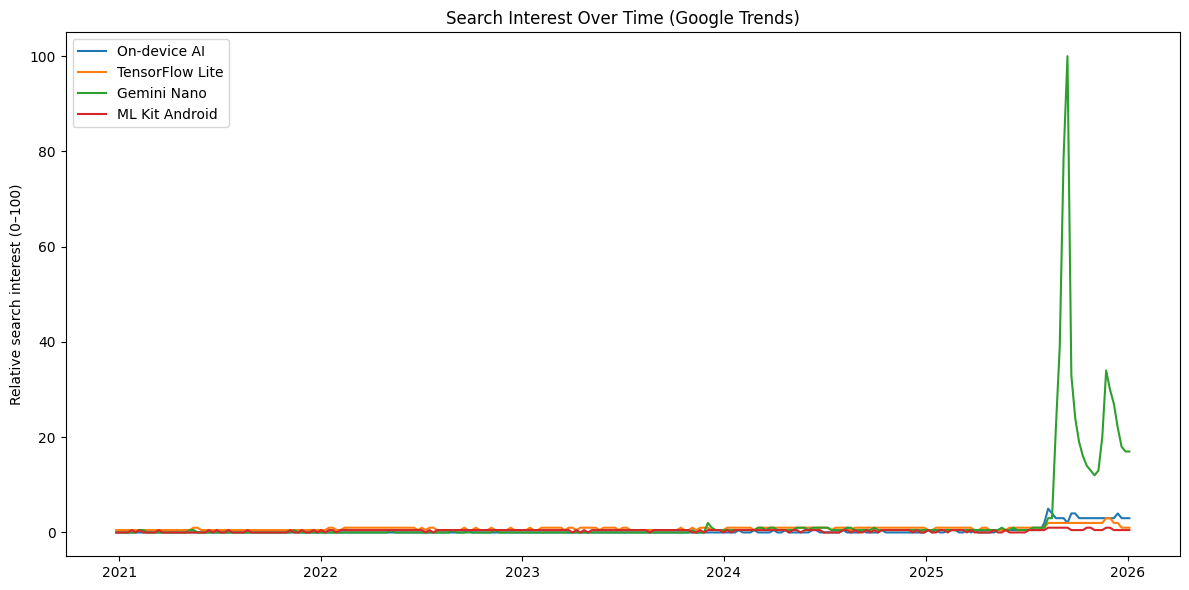

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for col, label in [('on_device_ai', 'On-device AI'), ('tensorflow_lite', 'TensorFlow Lite'),
                    ('gemini_nano', 'Gemini Nano'), ('ml_kit', 'ML Kit Android')]:
    plt.plot(trends_df['week'], trends_df[col], label=label)
plt.title('Search Interest Over Time (Google Trends)')
plt.ylabel('Relative search interest (0–100)')
plt.legend()
plt.tight_layout()
plt.savefig('chart1_trends.png', dpi=150)
plt.show()

In [7]:
so_df = pd.read_csv('stackoverflow_2021_2022.csv')

# Combine the two ML Kit tags into one
so_df['tag'] = so_df['tag'].replace({'firebase-mlkit': 'mlkit', 'google-mlkit': 'mlkit'})
so_df = so_df.groupby(['year', 'quarter', 'tag'], as_index=False)['question_count'].sum()

# Make a year-quarter label for plotting
so_df['period'] = so_df['year'].astype(str) + ' Q' + so_df['quarter'].astype(str)

so_pivot = so_df.pivot(index='period', columns='tag', values='question_count').fillna(0)
so_pivot

tag,coreml,mediapipe,mlkit,onnxruntime,tensorflow-lite
period,,,,,
2021 Q1,36,10,69,18,144
2021 Q2,32,35,60,8,142
2021 Q3,16,64,53,17,113
2021 Q4,23,58,39,21,86
2022 Q1,25,72,50,34,127
2022 Q2,34,80,61,18,124
2022 Q3,28,61,46,17,78


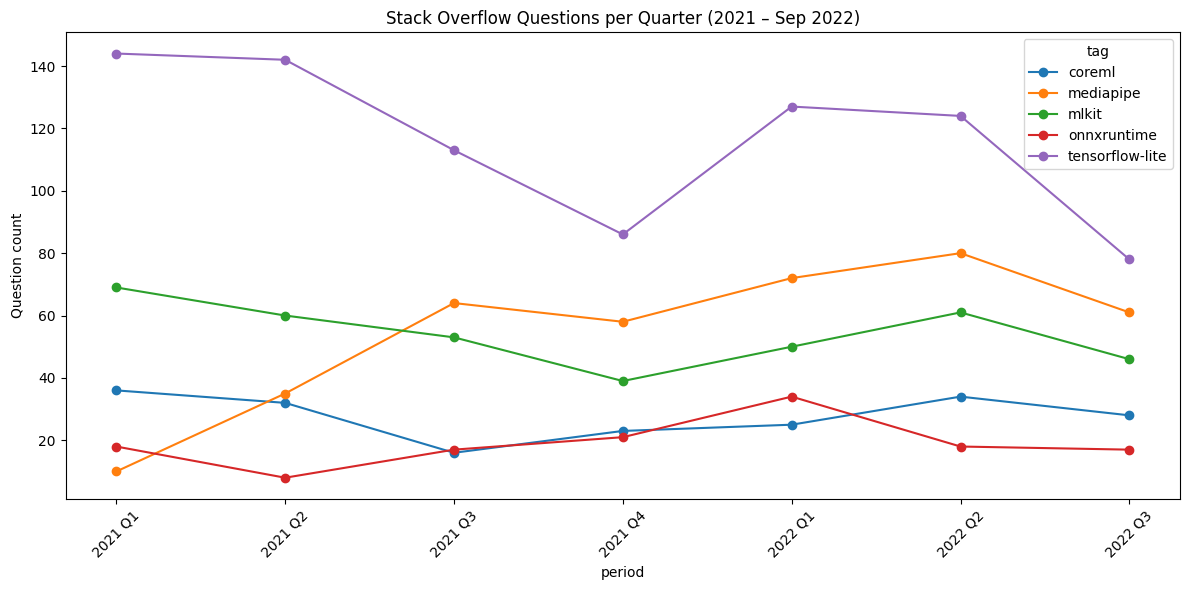

In [8]:
so_pivot.plot(figsize=(12, 6), marker='o')
plt.title('Stack Overflow Questions per Quarter (2021 – Sep 2022)')
plt.ylabel('Question count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart2_stackoverflow.png', dpi=150)
plt.show()

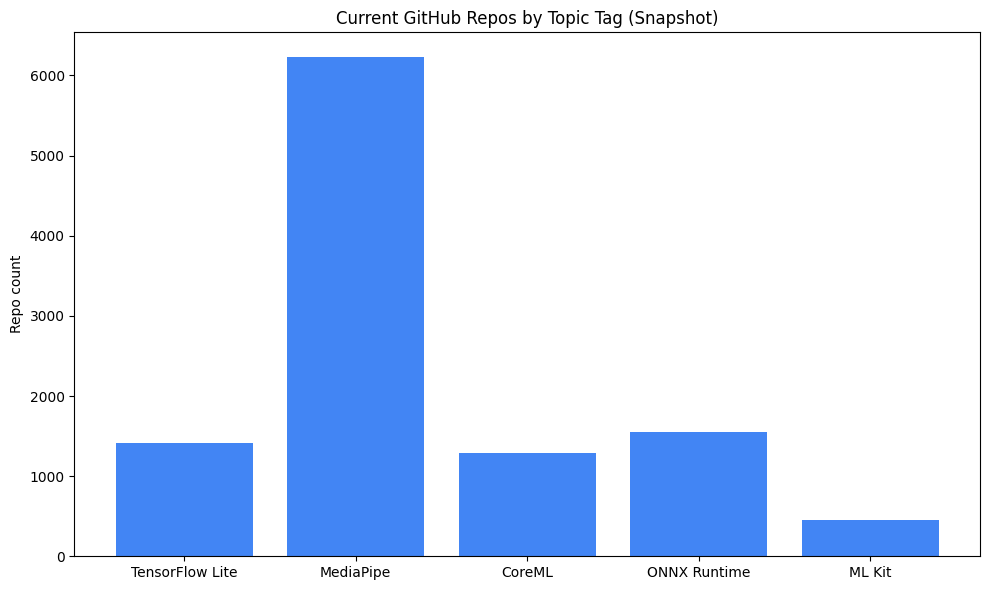

In [9]:
github_counts = {
    'TensorFlow Lite': 1418,
    'MediaPipe': 6227,
    'CoreML': 1294,
    'ONNX Runtime': 1555,
    'ML Kit': 450,
}

plt.figure(figsize=(10, 6))
plt.bar(github_counts.keys(), github_counts.values(), color='#4285F4')
plt.title('Current GitHub Repos by Topic Tag (Snapshot)')
plt.ylabel('Repo count')
plt.tight_layout()
plt.savefig('chart3_github.png', dpi=150)
plt.show()